In the model of synchoronous communication, computation advances in global rounds, where in each round processes send messages, receive them, and do some local computation.

In [309]:
import networkx as nx
import matplotlib.pyplot as plt

In [310]:
from collections import defaultdict


class Node:
    def __init__(self, node_id, neighbors, graph):
        self.node_id = node_id
        self.neighbors = neighbors
        self.graph = graph
        self.status = None
        self.state = node_id
        self.round = 0
        self.inbox = []
        self.outbox = defaultdict(list)

    def receive_message(self, message):
        self.inbox.append(message)

    def compute(self):
        if self.round == 0:
            self.broadcast(self.state)

        if self.inbox:
            minimum = self.inbox[0]

            for message in self.inbox[1:]:
                if message < minimum:
                    minimum = message

            if minimum < self.state:
                self.state = minimum
                self.status = "NON-ELECTED"

                self.broadcast(self.state)

        if self.state == self.node_id:
            self.status = "ELECTED"

        # Clear inbox after processing
        self.inbox = []

        # Update the networkx graph attributes for displaying the graph
        self.graph.nodes[self.node_id]["state"] = self.state
        self.graph.nodes[self.node_id]["status"] = self.status

        self.round += 1

    def broadcast(self, message):
        # Send the same message to all neighbors
        for neighbor in self.neighbors:
            self.outbox[neighbor].append(message)

In [311]:
def initialize_nodes(graph):
    # Create a dictionary of nodes where each node is initialized with its neighbors
    nodes = {}
    for node in graph.nodes():
        neighbors = list(graph.neighbors(node))
        nodes[node] = Node(node_id=node, neighbors=neighbors, graph=graph)
        # Initialize the graph's "state" attribute for each node
        graph.nodes[node]['state'] = None
        graph.nodes[node]['status'] = None
    return nodes

In [312]:
def simulate_round(graph, nodes):
    for u, v in graph.edges():
        # If node u has a message for v, deliver it to v
        # print(f"node {u} outbox: {nodes[u].outbox}")
        if v in nodes[u].outbox:
            for message in nodes[u].outbox[v]:
                nodes[v].receive_message(message)
                # print(f"node {u} has a message for {v}, the message is {message}")

        # If node v has a message for u, deliver it to u
        if u in nodes[v].outbox:
            for message in nodes[v].outbox[u]:
                nodes[u].receive_message(message)
                # print(f"node {v} has a message for {u}, the message is {message}")

    # Clear outbox for all nodes after messages sent
    for node in nodes.values():
        node.outbox.clear()

    for node in nodes.values():
        node.compute()


In [313]:
def display_graph(graph):
    # Position the nodes using a layout (e.g., spring layout)
    pos = nx.spring_layout(graph, seed=41)

    # Draw the graph
    nx.draw(graph, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, font_weight='bold')

    offset=(0, 0.10)

    # Adjust the label positions by adding the offset
    offset_pos = {node: (x + offset[0], y + offset[1]) for node, (x, y) in pos.items()}

    # Draw the state as labels on the nodes
    state_labels = {node: f"{data['state']}, {data['status']}" for node, data in graph.nodes(data=True)}
    nx.draw_networkx_labels(graph, offset_pos, labels=state_labels, font_color='red')

    # Show the plot
    plt.show()

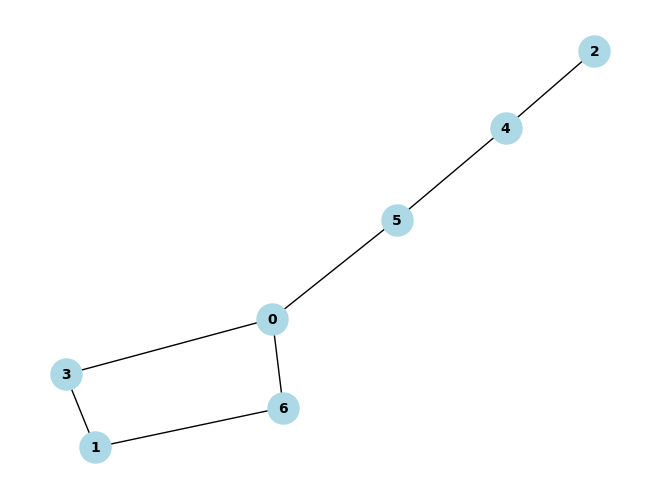

In [314]:
# G = nx.barabasi_albert_graph(16, 4, seed=42)
# G = nx.watts_strogatz_graph(20, 3, 0.1, seed=42)
G = nx.erdos_renyi_graph(7, 0.2, seed=45)

pos = nx.spring_layout(G, seed=41)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=500,
    font_size=10,
    font_weight="bold",
)

In [315]:
nodes = initialize_nodes(G)

for step in range(nx.diameter(G)):
    print(f"Step {step + 1}")
    simulate_round(G, nodes)


Step 1
Step 2
Step 3
Step 4
Step 5


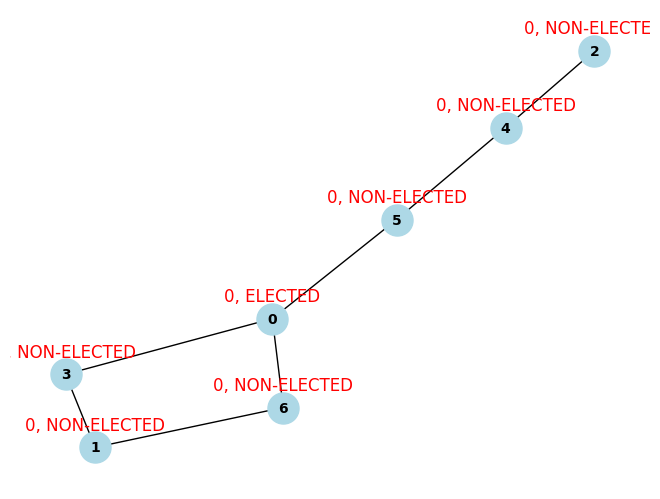

In [316]:
display_graph(G)

In [317]:
class BasicLE:
    def __init__(self, graph):
        self.graph = graph
        self.nodes = {}

    def initialize_nodes(self):
        # Create a dictionary of nodes where each node is initialized with its neighbors
        for node in self.graph.nodes():
            neighbors = list(self.graph.neighbors(node))
            self.nodes[node] = Node(node_id=node, neighbors=neighbors, graph=self.graph)
            # Initialize the graph's "state" attribute for each node
            self.graph.nodes[node]["state"] = None
            self.graph.nodes[node]["status"] = None

    def simulate_round(self):
        for u, v in self.graph.edges():

            # If node u has a message for v, deliver it to v
            if v in self.nodes[u].outbox:

                for message in self.nodes[u].outbox[v]:

                    self.nodes[v].receive_message(message)

            # If node v has a message for u, deliver it to u
            if u in self.nodes[v].outbox:
                for message in self.nodes[v].outbox[u]:
                    self.nodes[u].receive_message(message)

        # Clear outbox for all nodes after messages sent
        for node in self.nodes.values():
            node.outbox.clear()

        # Perform computations for each node
        for node in self.nodes.values():
            node.compute()

    def run(self):
        self.initialize_nodes()

        for step in range(nx.diameter(self.graph)):
            print(f"Step {step + 1}")
            self.simulate_round()

    def display_graph(self):
        # Position the nodes using a layout (e.g., spring layout)
        pos = nx.spring_layout(self.graph, seed=41)

        # Draw the graph
        nx.draw(
            self.graph,
            pos,
            with_labels=True,
            node_color="lightblue",
            node_size=500,
            font_size=10,
            font_weight="bold",
        )

        offset = (0, 0.10)

        # Adjust the label positions by adding the offset
        offset_pos = {
            node: (x + offset[0], y + offset[1]) for node, (x, y) in pos.items()
        }

        # Draw the state as labels on the nodes
        state_labels = {
            node: f"{data['state']}, {data['status']}"
            for node, data in self.graph.nodes(data=True)
        }
        nx.draw_networkx_labels(
            self.graph, offset_pos, labels=state_labels, font_color="red"
        )

        # Show the plot
        plt.show()

Step 1
Step 2
Step 3
Step 4
Step 5


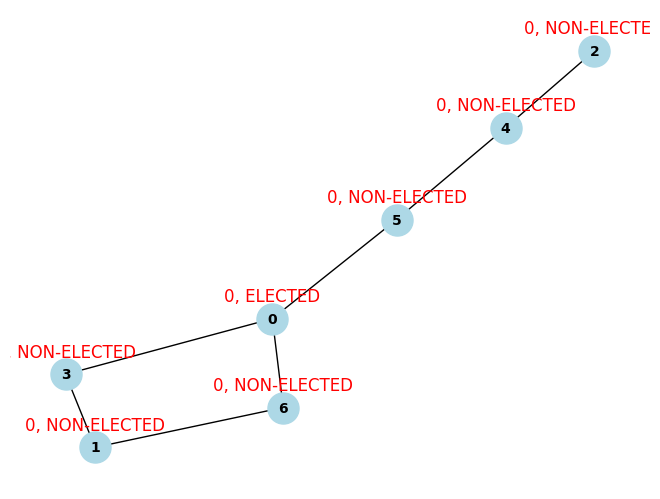

In [318]:
x = BasicLE(G)

x.run()
x.display_graph()